In this project, we collected data from various sources, cleaned, annotated and categorized them. In this notebook, we will conduct an exploratory data analysis of the collected text data.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from gensim.models import KeyedVectors

In [2]:
# Location of the cleaned text data
filepath = "../../data/data-final-cleaned.pkl"
#df = pd.read_csv(filepath)
df = pd.read_pickle(filepath)

In [3]:
df.head()

,Source,Category,Headline,Description,Link,Date,Author,Target
0,Copperbelt Energy,career,"[CEC, Career, Opportunity, GDP, Legal]","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 16:31:18+00:00,Lovejoy Musundire,0
1,Copperbelt Energy,career,"[CEC, Career, Opportunity, Assurance, Speciali...","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:15:28+00:00,Lovejoy Musundire,0
2,Copperbelt Energy,career,"[CEC, Career, Opportunity, Internal, Auditor, ...","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:14:39+00:00,Lovejoy Musundire,0
3,Copperbelt Energy,career,"[CEC, Career, Opportunity, Engineer, protection]","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:13:41+00:00,Lovejoy Musundire,0
4,Copperbelt Energy,career,"[CEC, Career, Opportunity, Mechanic, II]","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:13:05+00:00,Lovejoy Musundire,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14282 entries, 0 to 14343
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   Source       14282 non-null  object             
 1   Category     14282 non-null  object             
 2   Headline     14282 non-null  object             
 3   Description  14282 non-null  object             
 4   Link         14282 non-null  object             
 5   Date         14282 non-null  datetime64[ns, UTC]
 6   Author       14282 non-null  object             
 7   Target       14282 non-null  int64              
dtypes: datetime64[ns, UTC](1), int64(1), object(6)
memory usage: 1004.2+ KB


In [5]:
df.shape

(14282, 8)

In [6]:
source_count = df['Source'].value_counts()
print(source_count)

Source
Lusaka Times               6479
Lusaka Voice               1745
Daily Nations Zambia       1361
Zambia Eye                 1022
Kitwe Online                889
Mwebantu                    711
Zambia Monitor              627
Copperbelt Energy           445
Zambian Eye                 300
Daily Revelation Zambia     202
Zambia365                   130
Zambia Reports              119
News Invasion 24             84
Lusaka Star                  67
ZNBC                         64
Flava FM                     14
DailyMail                    10
Tech Africa News              7
Christian Voice               4
Daily Mail Zambia             2
Name: count, dtype: int64


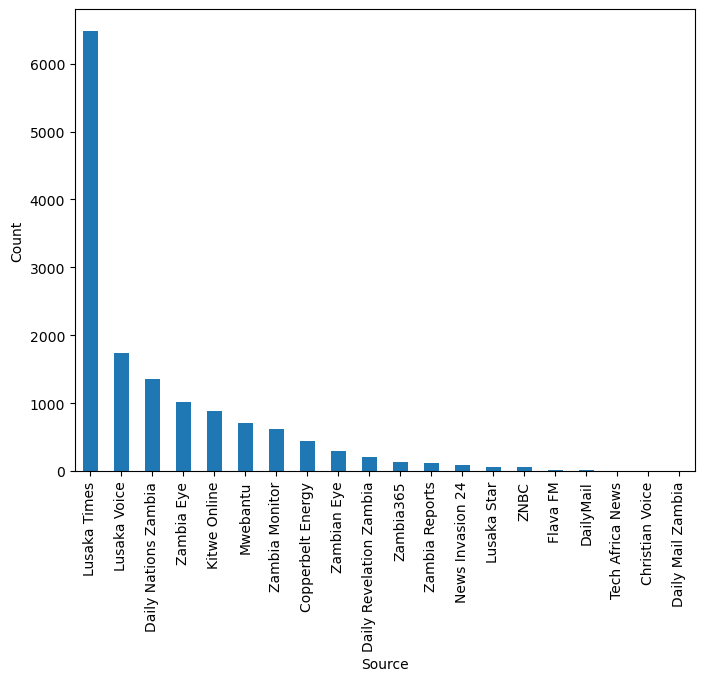

In [7]:
source_count.plot(kind="bar", figsize=(8,6))
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

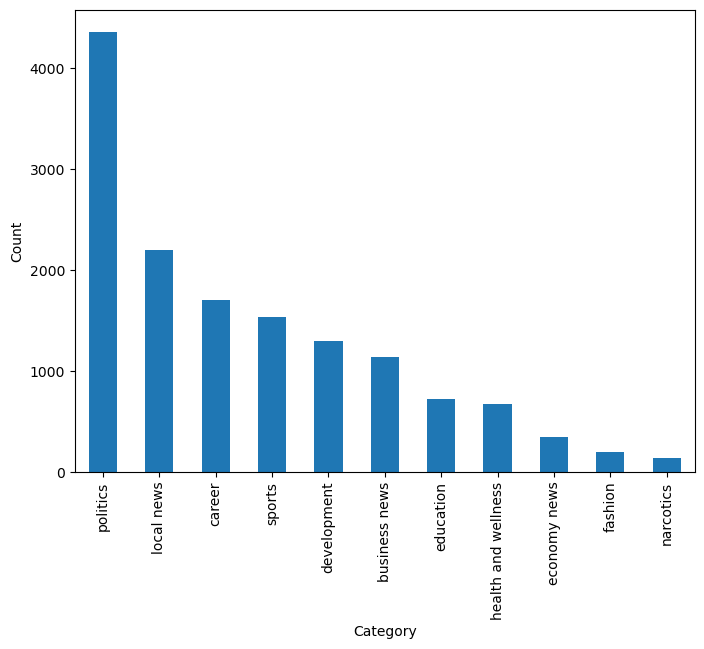

In [8]:
cat_count = df['Category'].value_counts()
cat_count.plot(kind="bar", figsize=(8,6))
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

Most of the news have been obtained from the Lusaka Times and the most of the news are from the politics and local news.

Target
1    8308
0    5974
Name: count, dtype: int64


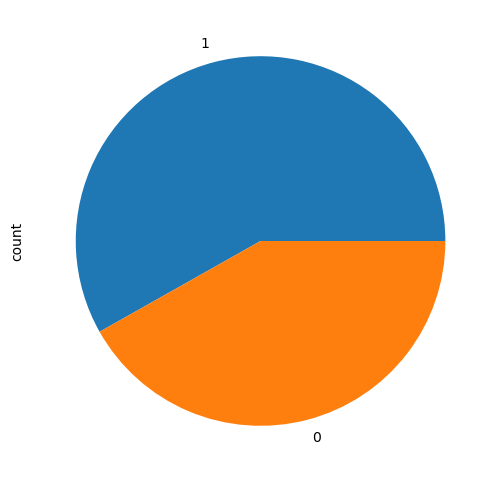

In [9]:
target_count = df['Target'].value_counts()
print(target_count)

target_count.plot.pie(figsize=(6,6))
plt.show()

Let's take a look at the word cloud from the text in the headline and descriptions:

In [10]:
comb_text = (df['Headline'] + df['Description']).apply(lambda x:" ".join(x))
print(comb_text)                    

0        CEC Career Opportunity GDP Legal currently car...
1        CEC Career Opportunity Assurance Specialist Sy...
2        CEC Career Opportunity Internal Auditor Inform...
3        CEC Career Opportunity Engineer protection cur...
4        CEC Career Opportunity Mechanic II currently c...
                               ...                        
14339    year OLD KITWE MAN arrest SEXUALLY abuse daugh...
14340    HH DIRECTS COPPERBELT PROVINCIAL ADMINISTRATIO...
14341    traffic police order rid ROADS INSANITY Michae...
14342    DEC ARRESTS LUSAKA COPPERBELT trafficking COCA...
14343    police officer CHILE family CLASH court KITWE ...
Length: 14282, dtype: object


In [11]:
comb_all = " ".join(comb_text)
#comb_all = comb_text.str.cat(sep=" ")
print(comb_all[:600])

CEC Career Opportunity GDP Legal currently career opportunity follow field GDP LEGAL Grade CEC GDP Contract Type fix Term location Kitwe fresh graduate Bachelor Law Degree LLB Advocate High Court Zambia seek acquire real world hand experience hone strength CEC Career Opportunity Assurance Specialist Systems currently career opportunity follow field ASSURANCE SPECIALIST SYSTEMS Grade CEC Contract Type Permanent location Kitwe role responsible implement strategic risk base internal audit plan assist functional head manage Assurance Internal Audit function accordance internal audit charter CEC Ca


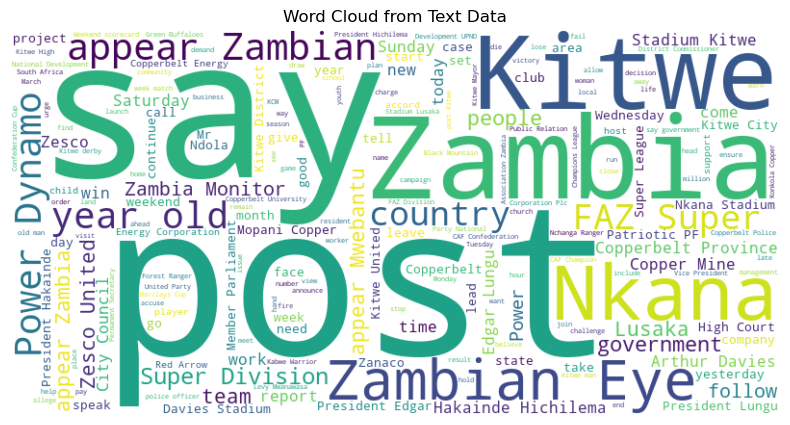

In [12]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(comb_all)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Text Data')
plt.show()

The wordcloud shows the most frequenctly occured words in the news we collected so far which is Zambia, Kitwe and also Post, say (which I think needed some cleaning).

In [13]:
df.groupby(by="Category")['Target'].sum()

Category
business news           783
career                  696
development             809
economy news            210
education               456
fashion                  63
health and wellness     419
local news             1212
narcotics                84
politics               3007
sports                  569
Name: Target, dtype: int64

It seems like most of the fake news are arising from politics and local news which makes sense.

<Axes: xlabel='Date'>

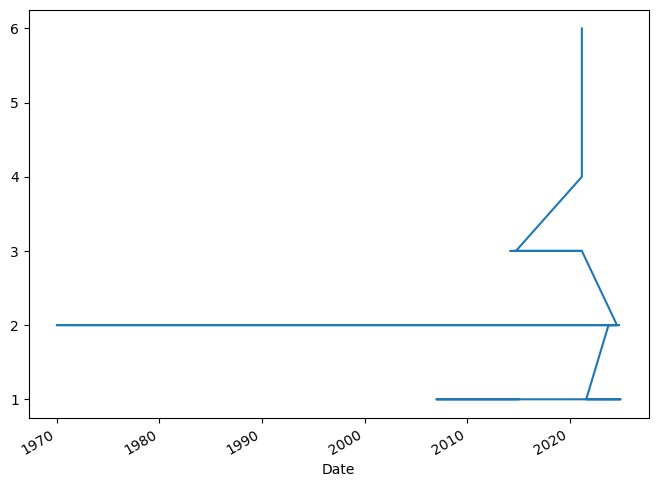

In [14]:
news_per_date = df["Date"].value_counts()
news_per_date.plot(kind='line', figsize=(8,6))
#plt.show()

### ML modeling
Before jumping into deep learning and transformers, we will use tf-idf to vectorize the each text data sample and we will try the following modeling methods:
1. Logistic regression
2. Naive Bayes
3. K-Nearest neighbours
4. Support vector machines

Since the data has already went through text preprocessing and data cleaning, we will be directly working with processed tokens. All we need to do is vectorization and splitting the data into train, validation and test sets. For this purpose we will use the standard classical linear models. The tf-idf vectorization produce high dimensional sparse vectors.

Most of the text classification problems are a linear algebra problem and can be solved with linear classifiers (linearly seperable in the tf-idf space). For example, tree based classifier are not used for this purpose as they use feature based splits which reduce the entropy/gini impurity. But it is not informative for a high dimensional sparse vector and tree splits does explore linearity well. So tree based models struggle with high dimensional vectors, sparse matrices and irrelevant features and they are not used for this purpose.

### TF-IDF vectorization
Term frequency - inverse document frequency measures the product of
1. how frequently a word appears in a document
2. how frequently the same word appears in other documents

This mesures the relative importants of each word with other documents. For eg. many stopping words are irrelevant as they appear in every documents and does not bring any values. When given a large dataset, tf-idf creates a unique vocubulary and then creates a vector for each sample based the words present and their relevence.

In [15]:
# calling the tf-idf vectorizer and vectorizing them.
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
comb_vec = vectorizer.fit_transform(comb_text)

In [16]:
# feature name and shape
feat = vectorizer.get_feature_names_out()
print(f"The feature vector size is {feat.shape}")
print(feat[10:20])

The feature vector size is (259847,)
['aaron musonda' 'aaron mwanza' 'aaron phiri' 'aaron sakamba'
 'aaron sikalumbi' 'aaron simfukwe' 'aawrds' 'aawrds gala' 'aaz'
 'aaz truck']


In [17]:
comb_vec.shape

(14282, 21085)

So after vectorization, there are roughly 21k features which is high dimensional and mostly sparse.

###  Data splitting into train and test sets

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(comb_vec, df['Target'], test_size=0.4, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_test, Y_test, test_size=0.5, random_state=42)

print(f"Training sample size : {Y_train.shape[0]}")
print(f"Validation sample size : {Y_val.shape[0]}")
print(f"Test sample size : {Y_test.shape[0]}")

Training sample size : 8569
Validation sample size : 2856
Test sample size : 2857


### Modeling
### Logistic Regression'
Logistic regression will take the inputs and fit a linear model and output the probability using a logistic function.

In [18]:
log_reg = LogisticRegression(random_state = 42)
log_reg.fit(X_train, Y_train)

# Lets make predictions from the trained model
ypred_train_log = log_reg.predict(X_train)
ypred_val_log = log_reg.predict(X_val)
ypred_test_log = log_reg.predict(X_test)

In [19]:
# the accurace score can also be obtained using the class function
acc_train_log = log_reg.score(X_train, Y_train)
acc_cv_log = log_reg.score(X_val, Y_val)
acc_test_log = log_reg.score(X_test, Y_test)

print(f" Training accuacy: {acc_train_log}, Validation accuracy: {acc_cv_log}, Test accuracy: {acc_test_log}")

 Training accuacy: 0.9025557241218345, Validation accuracy: 0.7899159663865546, Test accuracy: 0.8029401470073504


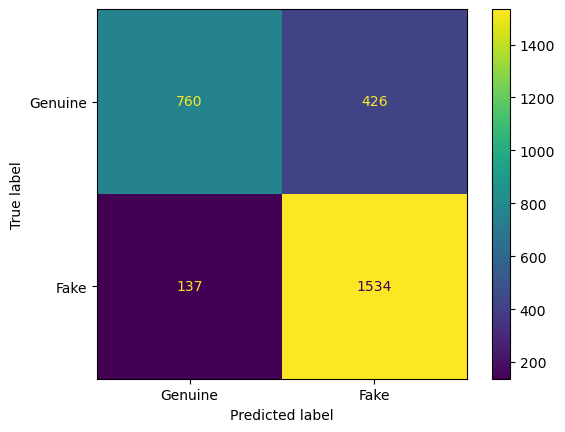

In [20]:
ConfusionMatrixDisplay.from_predictions(Y_test, ypred_test_log, display_labels = ['Genuine', 'Fake'])
plt.show()

In [21]:
print(classification_report(Y_test, ypred_test_log, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.85      0.64      0.73      1186
        Fake       0.78      0.92      0.84      1671

    accuracy                           0.80      2857
   macro avg       0.81      0.78      0.79      2857
weighted avg       0.81      0.80      0.80      2857



### K-Neaerst Neighbours:
KNN looks at the nearest n neighbours and make decisions based on the majority nature of the neighbours.

In [22]:
knn =  KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

# Lets make predictions from the trained model
ypred_train_knn = knn.predict(X_train)
ypred_val_knn = knn.predict(X_val)
ypred_test_knn = knn.predict(X_test)

In [23]:
# the accurace score can also be obtained using the class function
acc_train_knn = knn.score(X_train, Y_train)
acc_cv_knn = knn.score(X_val, Y_val)
acc_test_knn = knn.score(X_test, Y_test)

print(f" Training accuacy: {acc_train_knn}, Validation accuracy: {acc_cv_knn}, Test accuracy: {acc_test_knn}")

 Training accuacy: 0.8228498074454429, Validation accuracy: 0.728641456582633, Test accuracy: 0.7343367168358418


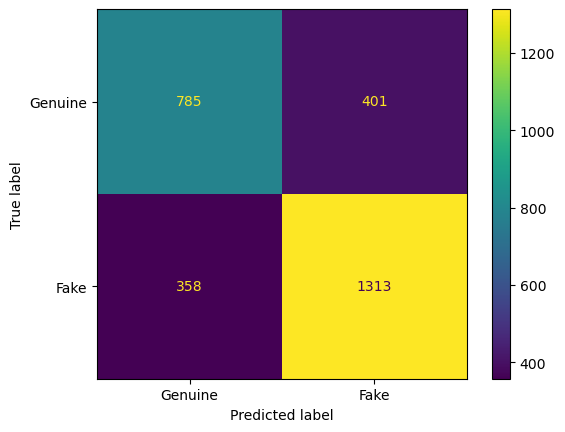

In [24]:
ConfusionMatrixDisplay.from_predictions(Y_test, ypred_test_knn, display_labels = ['Genuine', 'Fake'])
plt.show()

In [25]:
print(classification_report(Y_test, ypred_test_knn, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.69      0.66      0.67      1186
        Fake       0.77      0.79      0.78      1671

    accuracy                           0.73      2857
   macro avg       0.73      0.72      0.72      2857
weighted avg       0.73      0.73      0.73      2857



### Linear and Polynomial SVM Kernels

In [27]:
#Linear case
svm_lin_clf = LinearSVC(C=10, random_state=42, max_iter=5000) # C is the regularization parameter
svm_lin_clf.fit(X_train, Y_train)

ypred_train_svm_lin = svm_lin_clf.predict(X_train)
ypred_val_svm_lin = svm_lin_clf.predict(X_val)
ypred_test_svm_lin = svm_lin_clf.predict(X_test)

In [28]:
# the accurace score can also be obtained using the class function
acc_train_svm_lin = svm_lin_clf.score(X_train, Y_train)
acc_cv_svm_lin = svm_lin_clf.score(X_val, Y_val)
acc_test_svm_lin = svm_lin_clf.score(X_test, Y_test)

print(f" Training accuacy: {acc_train_svm_lin}, Validation accuracy: {acc_cv_svm_lin}, Test accuracy: {acc_test_svm_lin}")

 Training accuacy: 0.999066402147275, Validation accuracy: 0.8203781512605042, Test accuracy: 0.8295414770738537


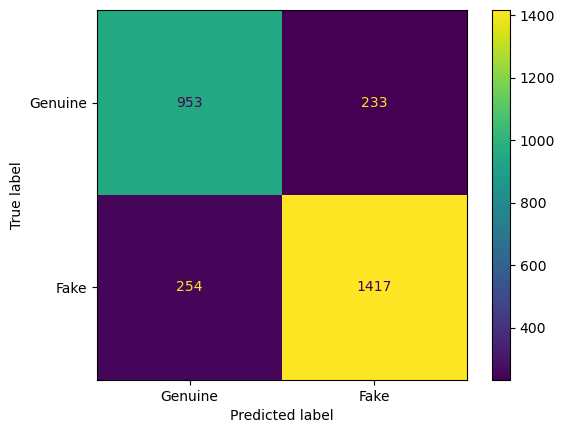

In [29]:
ConfusionMatrixDisplay.from_predictions(Y_test, ypred_test_svm_lin, display_labels = ['Genuine', 'Fake'])
plt.show()

In [30]:
print(classification_report(Y_test, ypred_test_svm_lin, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.79      0.80      0.80      1186
        Fake       0.86      0.85      0.85      1671

    accuracy                           0.83      2857
   macro avg       0.82      0.83      0.82      2857
weighted avg       0.83      0.83      0.83      2857



In [32]:
#Non-linear case
svm_poly_clf = SVC(kernel="poly", degree=2, C=1, random_state=42) # using a second degree polynomial
svm_poly_clf.fit(X_train, Y_train)

ypred_train_svm_poly = svm_poly_clf.predict(X_train)
ypred_val_svm_poly = svm_poly_clf.predict(X_val)
ypred_test_svm_poly = svm_poly_clf.predict(X_test)

# the accurace score can also be obtained using the class function
acc_train_svm_poly = svm_lin_clf.score(X_train, Y_train)
acc_cv_svm_poly = svm_lin_clf.score(X_val, Y_val)
acc_test_svm_poly = svm_lin_clf.score(X_test, Y_test)

print(f" Training accuacy: {acc_train_svm_poly}, Validation accuracy: {acc_cv_svm_poly}, Test accuracy: {acc_test_svm_poly}")

 Training accuacy: 0.999066402147275, Validation accuracy: 0.8203781512605042, Test accuracy: 0.8295414770738537


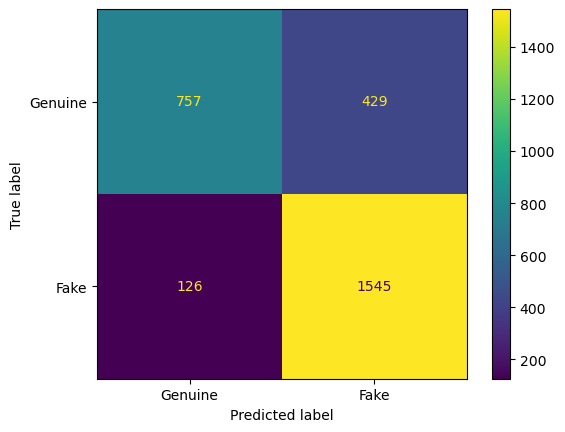

In [33]:
ConfusionMatrixDisplay.from_predictions(Y_test, ypred_test_svm_poly, display_labels = ['Genuine', 'Fake'])
plt.show()

In [35]:
print(classification_report(Y_test, ypred_test_svm_poly, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.86      0.64      0.73      1186
        Fake       0.78      0.92      0.85      1671

    accuracy                           0.81      2857
   macro avg       0.82      0.78      0.79      2857
weighted avg       0.81      0.81      0.80      2857



### Naive Bayes
Now we will also try the Naive Bayes classifier which uses the Bayes theorem under the hood.
P(c|d) = P(c) * P(d|c)/(P(d))

P(c|d): posterior probability of class c given data/document d (prob of your hypothesis after seeing the data)
p(c): Prior probability of class d (before seeing any data)
P(d|c): Likelihood or probability of observing data d given class c
P(d): probability of each document = constant (ignored)
NB makes the naive assumption that all the features are independent of each other given a particular class and here the word orders are not important (which is not true).

Then P(d|c) = P(w1|c)P(w2|c)....P(wn|c)

P(w1|c) = number of time w1 appears in class c/ number of words in class c. 
Now all you do is finding the class that maximized the posterior function. But everything is done in log space and multiple multiplication of small probabilities causing underflow error.

We will use the multinomial NB designed for working with discrete data here. Also, NB is a linear model in the log space.

In [37]:
nb_clf = MultinomialNB()
nb_clf.fit(X_train, Y_train)

# Lets make predictions from the trained model
ypred_train_nb = nb_clf.predict(X_train)
ypred_val_nb = nb_clf.predict(X_val)
ypred_test_nb = nb_clf.predict(X_test)

In [38]:
# the accurace score can also be obtained using the class function
acc_train_nb = nb_clf.score(X_train, Y_train)
acc_cv_nb = nb_clf.score(X_val, Y_val)
acc_test_nb = nb_clf.score(X_test, Y_test)

print(f" Training accuacy: {acc_train_nb}, Validation accuracy: {acc_cv_nb}, Test accuracy: {acc_test_nb}")

 Training accuacy: 0.7555140623176567, Validation accuracy: 0.7076330532212886, Test accuracy: 0.7196359817990899


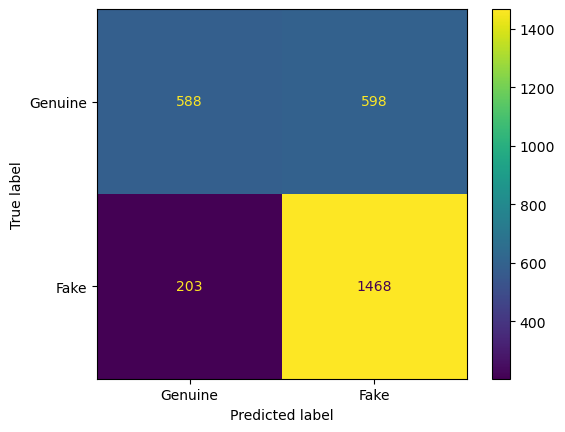

In [39]:
ConfusionMatrixDisplay.from_predictions(Y_test, ypred_test_nb, display_labels = ['Genuine', 'Fake'])
plt.show()

In [40]:
print(classification_report(Y_test, ypred_test_nb, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.74      0.50      0.59      1186
        Fake       0.71      0.88      0.79      1671

    accuracy                           0.72      2857
   macro avg       0.73      0.69      0.69      2857
weighted avg       0.72      0.72      0.71      2857



The precision and recall scores especially for the genuine class are lower compared to the previous models.

NB basically calculates the probabilites by taking the counts of words/feature s n each classs. Maybe a word count vector could be a better choice than the tf-idf vector. So let's try again NB with wordcount vectorizer and see what happens.

In [42]:
count_vectorizer = CountVectorizer()
count_vec = count_vectorizer.fit_transform(comb_text)

In [43]:
count_vec.shape

(14282, 21085)

In [46]:
X_train_count, X_test_count, Y_train_count, Y_test_count = train_test_split(count_vec, df['Target'], test_size=0.4, random_state=42)
X_val_count, X_test_count, Y_val_count, Y_test_count = train_test_split(X_test_count, Y_test_count, test_size=0.5, random_state=42)

print(f"Training sample size : {Y_train_count.shape[0]}")
print(f"Validation sample size : {Y_val_count.shape[0]}")
print(f"Test sample size : {Y_test_count.shape[0]}")

Training sample size : 8569
Validation sample size : 2856
Test sample size : 2857


In [47]:
nb_clf_count = MultinomialNB()
nb_clf_count.fit(X_train_count, Y_train_count)

# Lets make predictions from the trained model
ypred_train_nb_count = nb_clf_count.predict(X_train_count)
ypred_val_nb_count = nb_clf_count.predict(X_val_count)
ypred_test_nb_count = nb_clf_count.predict(X_test_count)

In [49]:
# the accurace score can also be obtained using the class function
acc_train_nb_count = nb_clf_count.score(X_train_count, Y_train_count)
acc_cv_nb_count = nb_clf_count.score(X_val_count, Y_val_count)
acc_test_nb_count = nb_clf_count.score(X_test_count, Y_test_count)

print(f" Training accuacy: {acc_train_nb_count}, Validation accuracy: {acc_cv_nb_count}, Test accuracy: {acc_test_nb_count}")

 Training accuacy: 0.8177150192554558, Validation accuracy: 0.7401960784313726, Test accuracy: 0.7455372768638432


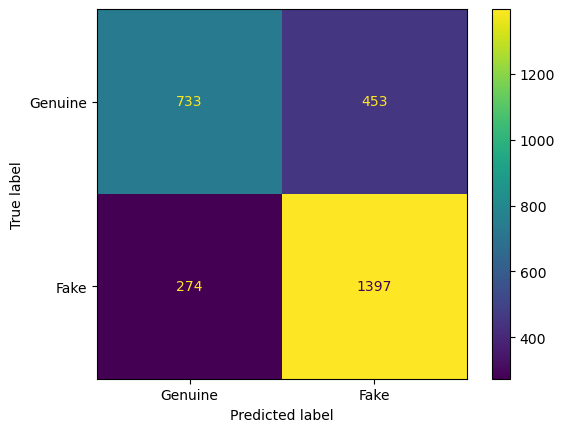

In [50]:
ConfusionMatrixDisplay.from_predictions(Y_test_count, ypred_test_nb_count, display_labels = ['Genuine', 'Fake'])
plt.show()

In [51]:
print(classification_report(Y_test_count, ypred_test_nb_count, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.73      0.62      0.67      1186
        Fake       0.76      0.84      0.79      1671

    accuracy                           0.75      2857
   macro avg       0.74      0.73      0.73      2857
weighted avg       0.74      0.75      0.74      2857



### Sequence Modeling with LSTMs
Now let's try to develop a recurrent network model using the LSTM units and we will feed the static embeddings for each word for classfication. We can train this network from scratch.
Word embeddings are vector representations of words which can be used for semantic understanding. Unlike the contextual embeddings, the static embedding remains fixed irrespective of the context.  Words with similiar meanings and context will be closer in the embedding vector space.

1. For each word in the vocabulary, we need to find a static emebedding value from the pretrained models. For this purpose, let' use the word2vec model.
2. Then we need to create a bidirectional LSTM network which needs to classify the sequence.

In [13]:
# Download the word2vec vectors
w2v = KeyedVectors.load_word2vec_format(
    "GoogleNews-vectors-negative300.bin",
    binary=True
)

FileNotFoundError: [Errno 2] No such file or directory: 'GoogleNews-vectors-negative300.bin'